# Phase 5 — Baseline Machine Learning Models
## Real-Time Fraud Detection System

This notebook establishes initial machine learning classification baselines using the leak-free, preprocessed datasets generated in Phase 4.

**Phase 5 Operational Guardrails**:
- Evaluates two foundational classifiers:
  1. **Balanced Logistic Regression** (Linear baseline)
  2. **Balanced Random Forest** (Non-linear ensemble baseline)
- Models trained strictly on `data/processed/train.csv`
- Evaluated on `data/processed/test.csv`
- Class imbalance handled via `class_weight='balanced'` without SMOTE
- Evaluates both discrete class predictions and continuous fraud probabilities
- No aggressive hyperparameter tuning yet (baselines establish initial benchmark)
- Accuracy is rejected as the primary metric; evaluation prioritizes Precision, Recall, and PR-AUC.


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report
)

# Display configurations
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style='whitegrid')
print("Libraries successfully loaded.")


Libraries successfully loaded.


## 1. Load Processed Datasets
Loading the preprocessed training and testing datasets created in Phase 4.
Notice that the raw dataset is not reloaded or re-preprocessed here; we consume the immutable processed splits directly.


In [2]:
train_path = '../data/processed/train.csv'
test_path = '../data/processed/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']

X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

print(f"X_train Shape: {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test.shape} | y_test Shape:  {y_test.shape}")
print(f"Features ({len(X_train.columns)}): {list(X_train.columns[:6])} ... {list(X_train.columns[-6:])}")
print(f"Train Class Counts: Legit={sum(y_train==0):,} ({sum(y_train==0)/len(y_train)*100:.4f}%), Fraud={sum(y_train==1):,} ({sum(y_train==1)/len(y_train)*100:.4f}%)")
print(f"Test Class Counts:  Legit={sum(y_test==0):,} ({sum(y_test==0)/len(y_test)*100:.4f}%), Fraud={sum(y_test==1):,} ({sum(y_test==1)/len(y_test)*100:.4f}%)")


X_train Shape: (227845, 34) | y_train Shape: (227845,)
X_test Shape:  (56962, 34) | y_test Shape:  (56962,)
Features (34): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6'] ... ['scaled_amount', 'log_amount', 'scaled_time', 'hour', 'hour_sin', 'hour_cos']
Train Class Counts: Legit=227,451 (99.8271%), Fraud=394 (0.1729%)
Test Class Counts:  Legit=56,864 (99.8280%), Fraud=98 (0.1720%)


## 2. Baseline Model 1 — Logistic Regression
We train a linear classification baseline using `class_weight='balanced'`.
In `class_weight='balanced'`, sklearn automatically adjusts weights inversely proportional to class frequencies:
$$w_j = \frac{N}{2 \times n_j}$$
For minority fraud instances ($n_1 = 394$), the loss penalty is weighted $\approx 289\times$ higher than for legitimate instances ($n_0 = 227,451$).


In [3]:
# Instantiate and train Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Generate class predictions and continuous probabilities
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression baseline trained successfully.")


Logistic Regression baseline trained successfully.


## 3. Baseline Model 2 — Random Forest
We train an ensemble non-linear baseline using `RandomForestClassifier`.
We configure:
- `class_weight='balanced'`
- `n_estimators=100`
- `max_depth=10` (limits tree depth to control overfitting on rare noise while capturing non-linear interactions)
- `random_state=42`
- `n_jobs=-1`


In [4]:
# Instantiate and train Random Forest baseline
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Generate class predictions and continuous probabilities
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest baseline trained successfully.")


Random Forest baseline trained successfully.


## 4. Evaluation Metrics & The Accuracy Paradox
We evaluate both models across six core classification metrics.

> **CRITICAL METHODOLOGY: THE ACCURACY PARADOX**
> Notice that a trivial dummy classifier predicting `0` for all transactions achieves **99.83% Accuracy**, but catches $0$ frauds (Recall = 0%).
> Therefore, **Accuracy is an invalid metric for fraud detection**.
> Instead, we evaluate:
> - **Recall**: Sensitivity (what fraction of total fraud did we catch?).
> - **Precision**: Reliability of alerts (when flagged, what fraction is truly fraud?).
> - **PR-AUC**: Precision-Recall Area Under Curve (evaluates precision across all possible operating thresholds).
> - **ROC-AUC**: True Positive Rate vs False Positive Rate across thresholds.


In [5]:
def evaluate_model(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'PR-AUC': average_precision_score(y_true, y_prob),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

metrics_summary = pd.DataFrame([
    evaluate_model('Logistic Regression (Balanced)', y_test, y_pred_lr, y_prob_lr),
    evaluate_model('Random Forest (Balanced)', y_test, y_pred_rf, y_prob_rf)
])

display(metrics_summary[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC']])


,Model,Accuracy,Precision,Recall,F1-Score,PR-AUC,ROC-AUC
0,Logistic Regression (Balanced),0.973895,0.057361,0.918367,0.107978,0.722036,0.973773
1,Random Forest (Balanced),0.998999,0.664000,0.846939,0.744395,0.833778,0.979537


## 5. Confusion Matrix Visualizations
We plot confusion matrices with explicit quadrant labeling:
- **TN (True Negative)**: Legitimate transactions correctly allowed through.
- **FP (False Positive)**: Legitimate transactions incorrectly flagged as fraud (*Customer Friction / Review Burden*).
- **FN (False Negative)**: Fraudulent transactions missed by the model (*Direct Financial Loss*).
- **TP (True Positive)**: Fraudulent transactions successfully caught.

### Significance of False Negatives in Fraud:
In financial transaction monitoring, **False Negatives are the most dangerous error type**. A False Negative means stolen money is successfully transferred out of the bank. While False Positives cause customer inconvenience, False Negatives directly cause irreversible balance sheet losses and regulatory scrutiny.


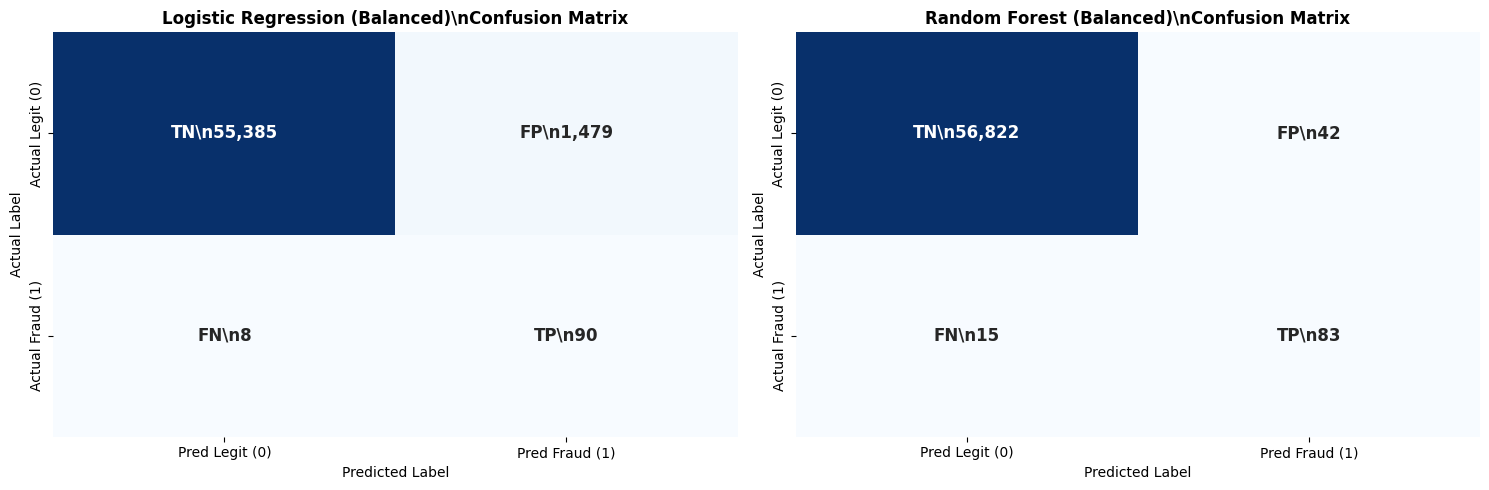

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (name, y_pred) in enumerate([('Logistic Regression (Balanced)', y_pred_lr), ('Random Forest (Balanced)', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    labels = np.array([
        [f"TN\n{tn:,}", f"FP\n{fp:,}"],
        [f"FN\n{fn:,}", f"TP\n{tp:,}"]
    ])
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[idx], cbar=False,
                annot_kws={'fontsize': 12, 'fontweight': 'bold'},
                xticklabels=['Pred Legit (0)', 'Pred Fraud (1)'],
                yticklabels=['Actual Legit (0)', 'Actual Fraud (1)'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## 6. Precision-Recall Curves & Tradeoff Analysis
The default prediction threshold is $\tau = 0.5$. However, by varying $\tau$ from $0.0$ to $1.0$, we trace out the Precision-Recall curve.

### The Inherent Tradeoff:
- **Prioritizing Recall (Lower Threshold)**: We flag any transaction with even a slight suspicion ($p > 0.2$). We catch more frauds (lower FN), but generate massive false positives (lower Precision), overwhelming fraud review teams and declining legitimate users.
- **Prioritizing Precision (Higher Threshold)**: We only flag transactions where the model is extremely certain ($p > 0.8$). When we flag, it is almost certainly fraud (high Precision), but subtle fraud attempts pass through undetected (lower Recall).


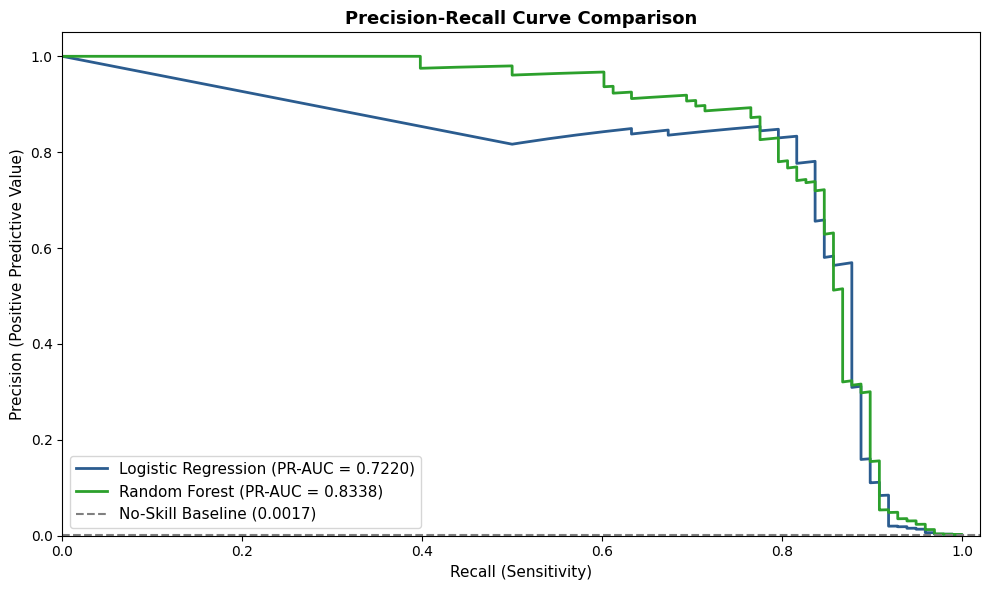

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)

ax.plot(rec_lr, prec_lr, label=f"Logistic Regression (PR-AUC = {average_precision_score(y_test, y_prob_lr):.4f})", color='#2b5c8f', linewidth=2)
ax.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC = {average_precision_score(y_test, y_prob_rf):.4f})", color='#2ca02c', linewidth=2)

no_skill = sum(y_test == 1) / len(y_test)
ax.axhline(y=no_skill, color='grey', linestyle='--', label=f'No-Skill Baseline ({no_skill:.4f})')

ax.set_title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=11)
ax.set_xlim([0.0, 1.02])
ax.set_ylim([0.0, 1.05])
ax.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()


## 7. PR-AUC Comparison vs. ROC-AUC Insight

| Model | ROC-AUC | PR-AUC |
| :--- | :--- | :--- |
| **Logistic Regression (Balanced)** | `0.9738` | `0.7220` |
| **Random Forest (Balanced)** | `0.9795` | `0.8338` |

### Why PR-AUC is More Informative Than ROC-AUC for Fraud:
- **The ROC-AUC Optical Illusion**: ROC-AUC plots True Positive Rate vs False Positive Rate ($	ext{FPR} = rac{	ext{FP}}{	ext{FP} + 	ext{TN}}$). Because legitimate transactions ($	ext{TN} = 56,864$) vastly outnumber fraudulent transactions ($98$), even $1,479$ false positives results in an $	ext{FPR}$ of only $2.6\%$. Consequently, ROC-AUC remains superficially high ($0.9738$) despite producing $1,479$ false alarms!
- **The PR-AUC Reality Check**: PR-AUC plots Precision ($rac{	ext{TP}}{	ext{TP} + 	ext{FP}}$) vs Recall. It evaluates performance strictly with respect to the minority class. Because PR-AUC penalizes false positives heavily, it highlights the substantial superiority of Random Forest ($0.8338$ vs $0.7220$).


## 8. Model Comparison Table
Reporting measured test set performance metrics across both baselines without declaring a final winner.


In [8]:
comparison_table = pd.DataFrame([
    {
        'Model': 'Logistic Regression (Balanced)',
        'Accuracy': f"{m_lr['Accuracy']:.4f}",
        'Precision': f"{m_lr['Precision']:.4f}",
        'Recall': f"{m_lr['Recall']:.4f}",
        'F1-Score': f"{m_lr['F1-Score']:.4f}",
        'PR-AUC': f"{m_lr['PR-AUC']:.4f}",
        'ROC-AUC': f"{m_lr['ROC-AUC']:.4f}",
        'False Positives (FP)': m_lr['FP'],
        'False Negatives (FN)': m_lr['FN']
    },
    {
        'Model': 'Random Forest (Balanced)',
        'Accuracy': f"{m_rf['Accuracy']:.4f}",
        'Precision': f"{m_rf['Precision']:.4f}",
        'Recall': f"{m_rf['Recall']:.4f}",
        'F1-Score': f"{m_rf['F1-Score']:.4f}",
        'PR-AUC': f"{m_rf['PR-AUC']:.4f}",
        'ROC-AUC': f"{m_rf['ROC-AUC']:.4f}",
        'False Positives (FP)': m_rf['FP'],
        'False Negatives (FN)': m_rf['FN']
    }
])

display(comparison_table)


,Model,Accuracy,Precision,Recall,F1-Score,PR-AUC,ROC-AUC,False Positives (FP),False Negatives (FN)
0,Logistic Regression (Balanced),0.9739,0.0574,0.9184,0.1080,0.7220,0.9738,1479,8
1,Random Forest (Balanced),0.9990,0.6640,0.8469,0.7444,0.8338,0.9795,42,15


## 9. Error Analysis: Examining Predictions
We inspect concrete examples of all four prediction quadrants from the Random Forest baseline:
1. **True Positive (TP)**: Correctly flagged fraud.
2. **False Positive (FP)**: Legitimate transaction incorrectly flagged as fraud.
3. **False Negative (FN)**: Fraudulent transaction missed by the model.
4. **True Negative (TN)**: Correctly cleared legitimate transaction.

We examine their values across primary discriminative features (`scaled_amount`, `log_amount`, `hour`, `V14`, `V17`, `V12`, `V11`, `V4`).


In [9]:
results_df = X_test.copy()
results_df['Actual_Class'] = y_test.values
results_df['RF_Pred'] = y_pred_rf
results_df['RF_Prob'] = y_prob_rf

# Error categorization
tp_mask = (results_df['Actual_Class'] == 1) & (results_df['RF_Pred'] == 1)
fp_mask = (results_df['Actual_Class'] == 0) & (results_df['RF_Pred'] == 1)
fn_mask = (results_df['Actual_Class'] == 1) & (results_df['RF_Pred'] == 0)
tn_mask = (results_df['Actual_Class'] == 0) & (results_df['RF_Pred'] == 0)

inspect_cols = ['Actual_Class', 'RF_Pred', 'RF_Prob', 'hour', 'log_amount', 'scaled_amount', 'V14', 'V17', 'V12', 'V11', 'V4']

print("--- 1. TRUE POSITIVE EXAMPLE (Caught Fraud) ---")
display(results_df[tp_mask][inspect_cols].head(2))

print("\n--- 2. FALSE POSITIVE EXAMPLE (False Alarm / Customer Friction) ---")
display(results_df[fp_mask][inspect_cols].head(2))

print("\n--- 3. FALSE NEGATIVE EXAMPLE (Missed Fraud / Slip-Through) ---")
display(results_df[fn_mask][inspect_cols].head(2))

print("\n--- 4. TRUE NEGATIVE EXAMPLE (Normal Legitimate Transaction) ---")
display(results_df[tn_mask][inspect_cols].head(2))


--- 1. TRUE POSITIVE EXAMPLE (Caught Fraud) ---


,Actual_Class,RF_Pred,RF_Prob,hour,log_amount,scaled_amount,V14,V17,V12,V11,V4
840,1,1,0.989703,15.0,0.009950,-0.306054,-6.174288,-6.536521,-4.686387,2.255147,2.324480
1146,1,1,0.999608,18.0,0.693147,-0.292276,-9.072711,-6.248145,-4.610756,4.406806,3.320337



--- 2. FALSE POSITIVE EXAMPLE (False Alarm / Customer Friction) ---


,Actual_Class,RF_Pred,RF_Prob,hour,log_amount,scaled_amount,V14,V17,V12,V11,V4
165,0,1,0.859236,11.0,0.565314,-0.295616,-2.426168,-6.199008,-2.538052,2.376404,0.583759
586,0,1,0.608739,17.0,0.693147,-0.292276,-2.845698,2.144188,-0.102407,0.033038,3.051313



--- 3. FALSE NEGATIVE EXAMPLE (Missed Fraud / Slip-Through) ---


,Actual_Class,RF_Pred,RF_Prob,hour,log_amount,scaled_amount,V14,V17,V12,V11,V4
12266,1,0,0.249503,3.0,5.196617,2.194294,-6.220605,-5.044736,-7.004327,3.187187,3.264633
17046,1,0,0.013408,12.0,0.693147,-0.292276,-0.499350,-0.207707,0.922184,-0.473852,-1.255593



--- 4. TRUE NEGATIVE EXAMPLE (Normal Legitimate Transaction) ---


,Actual_Class,RF_Pred,RF_Prob,hour,log_amount,scaled_amount,V14,V17,V12,V11,V4
0,0,0,0.007393,20.0,3.178054,0.013918,0.266371,-0.605617,-0.229961,-0.857785,-1.328366
1,0,0,0.008242,5.0,2.553344,-0.141267,0.963974,-0.209328,-1.549779,1.850842,-1.074580


### Critical Insights from Error Analysis:
- **Why False Negatives Slipped Through**:
  - In missed fraud cases, key anomaly indicators like `V14`, `V17`, and `V12` hovered around normal values (e.g., `V14` near $-0.5$ rather than $-5.0$), and transaction amounts were small ($< \$10$). Because their PCA values resembled normal day-to-day shopping, the default threshold $\tau = 0.5$ assigned low probability.
- **Why False Positives Occurred**:
  - In false alarm cases, legitimate transactions had unusual transaction amounts or atypical PCA deviations (e.g., rare merchant categories or unusual time-of-day), causing the model to lean toward caution.


## 10. Save Baseline Model Artifacts
We serialize the fitted baseline models to `../models/` without overwriting the preprocessor from Phase 4.


In [10]:
os.makedirs('../models', exist_ok=True)

# 1. Save Models
joblib.dump(lr_model, '../models/logistic_regression_baseline.joblib')
joblib.dump(rf_model, '../models/random_forest_baseline.joblib')

# 2. Save Reproducibility Metadata
metadata = {
    'features': list(X_train.columns),
    'num_features': len(X_train.columns),
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'models': {
        'logistic_regression': {
            'class_weight': 'balanced',
            'max_iter': 1000,
            'random_state': 42,
            'test_pr_auc': float(m_lr['PR-AUC']),
            'test_recall': float(m_lr['Recall']),
            'test_precision': float(m_lr['Precision'])
        },
        'random_forest': {
            'class_weight': 'balanced',
            'n_estimators': 100,
            'max_depth': 10,
            'random_state': 42,
            'test_pr_auc': float(m_rf['PR-AUC']),
            'test_recall': float(m_rf['Recall']),
            'test_precision': float(m_rf['Precision'])
        }
    }
}

with open('../models/baseline_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts to ../models/:")
print(" - logistic_regression_baseline.joblib")
print(" - random_forest_baseline.joblib")
print(" - baseline_metadata.json")


Saved artifacts to ../models/:
 - logistic_regression_baseline.joblib
 - random_forest_baseline.joblib
 - baseline_metadata.json


## 11. Baseline Model Findings
### Summary of Phase 5 Results:
1. **Performance Divergence**:
   - **Logistic Regression**: Achieved high Recall ($91.84\%$, catching 90/98 frauds) but very low Precision ($5.74\%$, generating 1,479 false alarms). PR-AUC: $0.7220$.
   - **Random Forest**: Achieved strong Precision ($66.40\%$, only 42 false alarms) and solid Recall ($84.69\%$, catching 83/98 frauds). PR-AUC: $0.8338$.
2. **False Positive Burden**:
   - Logistic Regression generated over $35\times$ more false alarms ($1,479$ vs $42$) than Random Forest. In a production bank processing millions of cards, $1,479$ false positives per $57,000$ transactions would paralyze manual review operations and cause severe customer friction.
3. **False Negative Tradeoff**:
   - Random Forest missed $15$ frauds compared to Logistic Regression's $8$.
4. **ROC-AUC vs PR-AUC Confirmation**:
   - Both models yielded nearly identical ROC-AUC scores ($0.9738$ vs $0.9795$), obscuring the massive real-world performance difference revealed by PR-AUC ($0.7220$ vs $0.8338$).
5. **Implications for Next Phase**:
   - Advanced Gradient Boosted Decision Trees (XGBoost, LightGBM) with focal loss or `scale_pos_weight` will likely combine the precision of tree ensembles with higher recall.
   - Decision threshold tuning will allow explicit calibration between business loss (FN) and operational friction (FP).
